# Lattice-Boltzmann (LB) simulation of von Karman ...


This is a modified version of a [LB python code for 2D flow around obstacles](https://palabos.unige.ch/get-started/lattice-boltzmann/lattice-boltzmann-sample-codes-various-other-programming-languages/) by
 Copyright (C) 2013 FlowKit Ltd, Lausanne, Switzerland
E-mail contact: contact@flowkit.com

modified by Richard Sear summer 2020 to 2026
email: r.sear@surrey.ac.uk and richardsear.me

Below is the copyright text from the FlowKit code,which also applies to this code:

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License, either version 3 of the License, or (at your option) any later version.

First import things....



In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import os
from IPython.display import display, clear_output
%matplotlib inline

### Lattice constants etc

The LB method discretises the velocities of each fluid element on the lattice into 9 values (stationary plus 8 points of the compass), these are the ```lattice_vec``` array, eg ```lattice_vec[1]=[0,-1]``` points West, ie to the left. And theweights ```t``` are the fractions of the fluid at a site heading in that direction, eg as ```t[1]=1/9``` one nineth of the fluid at a site is heading West.

Below 'noslip onsite bounce back ' is used to define boundary conditions (BCs) at a solid surface. They are bounce back in the sense that a solid obstacle the fluid moving West, element 1, 'bounces back' into element 2, which is moving East, and so on. 

In [2]:
###### Lattice Constants #######################################################
# standard D2Q9 LB
q = 9
#c = np.array([(x,y) for x in [0,-1,1] for y in [0,-1,1]]) # Lattice velocities.
#print(c)
lattice_vec=np.zeros((9,2),dtype=int)
lattice_vec[0]=[0,0]
lattice_vec[1]=[0,-1]
lattice_vec[2]=[0,1]
lattice_vec[3]=[-1,0]
lattice_vec[4]=[-1,-1]
lattice_vec[5]=[-1,1]
lattice_vec[6]=[1,0]
lattice_vec[7]=[1,-1]
lattice_vec[8]=[1,1]
for i in range(q):
    print('lattice velocity vector ',i,' = ',lattice_vec[i])
# set weights, off diagonal ones are 1/36, all for D2Q9 model
t = np.ones(q)/36.0
# 4 cardinal point weights 1/9
t[1]=1.0/9.0
t[2]=1.0/9.0
t[3]=1.0/9.0
t[6]=1.0/9.0
# 0 velocity weight is 4/9
t[0]=4.0/9.0
print('weights ',t)
#t[np.asarray([np.linalg.norm(ci)<1.1 for ci in c])] = 1./9.; t[0] = 4./9.
#print('weights ',t)
#
noslip = [lattice_vec.tolist().index((-lattice_vec[i]).tolist()) for i in range(q)] 
print('noslip onsite bounce back ',noslip)
i_set_neg_ux = np.arange(q)[np.asarray([ci[0]<0  for ci in lattice_vec])] # Unknown on right wall.
print('lattice vectors pointing to - x ',i_set_neg_ux)
i_set_0_ux = np.arange(q)[np.asarray([ci[0]==0 for ci in lattice_vec])] # Vertical middle.
print('lattice vectors with 0 x comp ',i_set_0_ux)
i_set_pos_ux = np.arange(q)[np.asarray([ci[0]>0  for ci in lattice_vec])] # Unknown on left wall.
print('lattice vectors pointing to + x i3',i_set_pos_ux)

lattice velocity vector  0  =  [0 0]
lattice velocity vector  1  =  [ 0 -1]
lattice velocity vector  2  =  [0 1]
lattice velocity vector  3  =  [-1  0]
lattice velocity vector  4  =  [-1 -1]
lattice velocity vector  5  =  [-1  1]
lattice velocity vector  6  =  [1 0]
lattice velocity vector  7  =  [ 1 -1]
lattice velocity vector  8  =  [1 1]
weights  [0.44444444 0.11111111 0.11111111 0.11111111 0.02777778 0.02777778
 0.11111111 0.02777778 0.02777778]
noslip onsite bounce back  [0, 2, 1, 6, 8, 7, 3, 5, 4]
lattice vectors pointing to - x  [3 4 5]
lattice vectors with 0 x comp  [0 1 2]
lattice vectors pointing to + x i3 [6 7 8]


# LB Equilibrium distribution function.

In a gas the distribution of velocities is given by the [Maxwell-Boltzmann distribution](https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution). The LB megthod does two things, it puts the fluid on a lattice, which greatly speeds up the calculation, and it does a Taylor expansion of the Maxwell-Boltzmann distribution, which is why below ```feq``` has linear and quadratic terms but no exponential, as Maxwell-Boltzmann does. This Taylor expansion means that LB only works at flow speeds much less than the speed of sound. It is in effect a small Mach number Taylor expansion.

In [3]:
def equilibrium(rho,u):            
#    cu   = 3.0 * np.dot(c,u.transpose(1,0,2))
# not in Einstein summation, summing over i which is 0 to 8 and is over lattice vector,
# leaves array over j (x and y components) and over m and n which are lattice in x and y
# oddly setting optimize=True seems to slow code down a bit!
    lattice_vec_dot_u = 3.0 * np.einsum('ij,jmn',lattice_vec,u)#,optimize=True)
    usqr = 1.5*(u[0,:,:]**2+u[1,:,:]**2)
    feq = np.zeros((q,nx,ny))
    for i in range(0,q): 
        feq[i,:,:] = rho*t[i]*(1.0+lattice_vec_dot_u[i]+0.5*lattice_vec_dot_u[i]**2-usqr)
    return feq

### Set up obstacle(s)

In this LB code obstacles are solid (not fluid) elements, and we just have a True/False (Boolean) variable ```inside_obs``` that is True for any element that is solid, False for any element that is fluid.

Below we set elements inside a circle to True but can make it any shape you want, and have more than one obstacle. Although LB codes can become unstable, so not guaranteed to work for all obstacles.

In [4]:
def obstacle_def(r):
##### now set True/False array for inside/outside disc
    inside_obs=np.zeros((nx,ny),dtype=bool)
    binary_obs=np.zeros((nx,ny))#,dtype=int)
    for i in range(0,nx):
        for j in range(0,ny):
            inside_obs[i,j]=False
            binary_obs[i,j]=0
# disc obstacle
            if( (i-x0)**2 + (j-y0)**2 < r**2  ): 
# inside obstacle
                inside_obs[i,j]=True
                binary_obs[i,j]=1              
#
    return inside_obs,binary_obs

### Functions to display while running

To watch the simulation in realtime we need to plot the flow field and then update it every ```subIter``` timesteps. Doing this without flickering in an annoying way is harder than it should be, below works when run locally and [Cocalc](https://cocalc.ai/) but flickers on Google Colab sorry.

Note that we need two functions, one called at the start to do the initial plot and one to update.

In [5]:

# Prep figure
def prep_animation():
    global fig,axs,n_coarse,im_disc,im,im_scalarfield,nx_plot,ny_plot
    #
    fig, axs = plt.subplots(1,figsize=(8,5))#,dpi=120)
    # for vector field plot, plot arrows every n_coarse sites
    n_coarse=5
    ux_plot=np.transpose(u[0,::n_coarse,::n_coarse])*(1.0-np.transpose(binary[::n_coarse,::n_coarse]))
    uy_plot=np.transpose(u[1,::n_coarse,::n_coarse])*(1.0-np.transpose(binary[::n_coarse,::n_coarse]))
    #
    print('shape of quiver plotting ',u[0,::n_coarse,::n_coarse].shape)
    nx_plot,ny_plot=u[0,::n_coarse,::n_coarse].shape
    x_plot=np.zeros((nx_plot,ny_plot))
    y_plot=np.zeros((nx_plot,ny_plot))
    for i in range(0,nx_plot):
        for j in range(0,ny_plot):
            x_plot[i,j]=float(i)*n_coarse
            y_plot[i,j]=float(j)*n_coarse
    # NB making scale number bigger makes arrows smaller!
    im=axs.quiver(np.transpose(x_plot),np.transpose(y_plot),ux_plot,uy_plot,scale=5)
    #
    dummy=np.zeros((nx,ny))
    # Set up colormap, with a distinct color for masked (circle) region
    cmap = plt.cm.seismic.copy()
    cmap.set_bad(color='green')  # color for the disc
    vscale=0.02#0.05
    im_scalarfield=axs.imshow(np.transpose(dummy),cmap=cmap, \
                        alpha=np.transpose(1.0-binary),vmin=-vscale,vmax=vscale)
    #
    axs.get_xaxis().set_visible(False)
    axs.get_yaxis().set_visible(False)
    axs.set_aspect('equal')
    return

def animation_plot():
    stringy='Re ='+'{:.0f}'.format(round(Re, 0))+' t/(2*r/u) = '+'{:.2f}'.format(round(tstep/T_d, 2))
    image1,image2=np.transpose(u[0,::n_coarse,::n_coarse])*(1.0-np.transpose(binary[::n_coarse,::n_coarse])), \
        np.transpose(u[1,::n_coarse,::n_coarse])*(1.0-np.transpose(binary[::n_coarse,::n_coarse]))
# update quiver plot
    im.set_UVC(image1,image2)
#
    if(plot_vorticity):
        vorticity = vorticity_calc()
# Mask the data inside the circle
        masked_data = np.ma.masked_where(obstacle, vorticity)
        stringy=stringy+' vorticity'
    else:
        dum1,dum2,dum3,shear_mag=shear_tensor()
# Mask the data inside the circle
        masked_data = np.ma.masked_where(obstacle, shear_mag)
        stringy=stringy+' shear'
# now plot masked data
    im_scalarfield.set_data(np.transpose(masked_data))
#
    plt.title(stringy,fontsize=18)
#
    clear_output(wait=True)
    display(fig)
    return

### Function to save data

If ```savedata``` is True below this will save flow fields at multiple time points for analysis by a separate code.

In [6]:
def save_data():
# assumes there is a directory called data already in directory this code runs in
    directory = 'data_vonKarman'
    file_name="uvort"+str(int(1000000+tstep)).zfill(4)+".npz"
    file_path = os.path.join(directory, file_name)
    print('saving to ',file_path)
    vorticity=vorticity_calc()
    np.savez_compressed(file_path,u=u,vorticity=vorticity, \
                            x0=x0,y0=y0,r=r,Re=Re,time=tstep/T_d,allow_pickle=True)
    print('\n')
    return

### Functions to compute the vorticity and shear

A von Karman street contains vortices that detach from the back (downstream) of the obstacle, in a vortex a property called the vorticity is large. The [vorticity](https://en.wikipedia.org/wiki/Vorticity) is defined as

$$
\vec{\omega}=\nabla\times\vec{u}
$$

for $\vec{u}=(u_x,u_y)$ the flow field. Note that the vorticity is a vector in general, but for our 2D simulations it is just one number so is a pseudoscalar. A function below calculates the vorticity from the flow field.

We want to know how the fluid velocity varies in space, in 2D this is given by

$$
\nabla\vec{u}=\left(
\begin{array}{cc}
\frac{\partial u_x}{\partial x} & \frac{\partial u_x}{\partial y}\\
\frac{\partial u_y}{\partial x} & \frac{\partial u_y}{\partial y}
\end{array}
\right)
$$

i.e., a 2 by 2 matrix of 4 numbers: the $x$ and $y$ derivatives of the two velocity components $u_x$ and $u_y$.

The rate-of-strain aka shear tensor is the symmetric version of this, ie the symmetric tensor

$$
\text{shear tensor}
=\left(
\begin{array}{cc}
S_{xx} & S_{xy}\\
S_{xy} & S_{yy}
\end{array}
\right)
$$

and

$$
\text{shear tensor}=\frac{1}{2}\left(\nabla\vec{u}+\nabla\vec{u}^T\right)
=\left(
\begin{array}{cc}
\frac{\partial u_x}{\partial x} & \frac{1}{2}\left(\frac{\partial u_x}{\partial y}+\frac{\partial u_y}{\partial x}\right)\\
\frac{1}{2}\left(\frac{\partial u_x}{\partial y}+\frac{\partial u_y}{\partial x}\right) & \frac{\partial u_y}{\partial y}
\end{array}
\right)
$$

where $\nabla\vec{u}^T$ is the transpose of the $\nabla\vec{u}$ matrix, i.e., with off-diagonal elements swapped.

Flows can be quite complex, but basically most of the important features depend on one or both the vorticity and shear.

As shear is a tensor it is often useful to have a scalar that approximates its size, typically we use

$$
\dot{\gamma}=\sqrt{2\left(S_{xx}^2+S_{yy}^2+2S_{xy}^2\right)}
$$



In [7]:
def vorticity_calc():
    vorticity = (np.roll(u[1,:,:], -1, axis=0) - np.roll(u[1,:,:], 1, axis=0)) - \
          (np.roll(u[0,:,:], -1, axis=1) - np.roll(u[0,:,:], 1, axis=1))
    return vorticity

def shear_tensor():
# first calculate u from fin
# sum the 9 components of fin on each lattice site to get density rho at each lattice site
    rho = np.sum(fin,axis=0)         
# Calculate velocity.
#    u = np.dot(c.transpose(), fin.transpose((1,0,2)))/rho
# here for using numpy's einsum, convention is: i is over q lattice vectors,
# j=0 (x) and  1 (y) and m and n are over x and y lattice sites, respectively
    u=np.einsum('imn,ij',fin,lattice_vec,optimize=True)/rho
    feq = equilibrium(rho,u)
#
    f1=fin-feq
    Sxx=np.zeros((nx,ny))
    Syy=np.zeros((nx,ny))
    Sxy=np.zeros((nx,ny))
    for i in range(q):
        Sxx=Sxx+f1[i,:]*lattice_vec[i,0]**2
        Syy=Syy+f1[i,:]*lattice_vec[i,1]**2
        Sxy=Sxy+f1[i,:]*lattice_vec[i,0]*lattice_vec[i,1]
    Sxx=Sxx*(-1.5*omega/rho)
    Syy=Syy*(-1.5*omega/rho)
    Sxy=Sxy*(-1.5*omega/rho)
    # one magnitude
    stress_mag=np.sqrt(2.0*(Sxx**2+Syy**2+2.0*Sxy**2))
    return Sxx,Syy,Sxy,stress_mag

### Parameters for run

1. ```nx``` and ```ny``` are size of lattice along $x$ (flow direction) and $y$. Typically want ```nx``` > 200 and ```ny``` > 100 but the larger they are the slower the simulation

2. ```x0``` and ```y0``` define the position of the disc obstacle, typically ```y0=ny/2``` so obstacle is in the middle

3. ```r``` is radius of disc obstacle, if it is less than 10 can cause lattice artifacts, eg ones thar develop along left-hand edge

4. ```Re```, ```uBCLB``` and ```omega``` are the Reynolds number, imposed flow speed along the left-hand edge, and relaxation rate, respectively. ```uBCLB``` is set much less than 1, as 1 is of order the speed of sound in the simulation, and LB simulations break near speed of sound. The Reynolds number is set to either get a von Karman street or not, and to achieve the Reynolds number you want, ```omega``` is set. In effect, you set the viscosity of the fluid to get the Reynolds number you want.

Finally it defines a timescale

$$
T_d=\frac{2r}{u}
$$

i.e., the disc diameter divided by the imposed flow speed, and so the time taken for an element in the fluid to flow past the disc. If Re is high enough for a von Karman street, you will need to run for at least 10 times that timescale, to allow a von Karman street to develop

In [8]:
# lattice size, flow is along x axis, periodic boundary conditions along y
nx = 400
ny = 140
print('nx,  ny ',nx,ny)
# cylinder centre at
x0=nx/4
y0=ny/2#+15
print('cylinder centre at ',round(x0,2),round(y0,2))
# cylinder radius
r=12
print('radius of discs in lattice units ',round(r,2))
# works by setting desired Reynolds number, Re, then (below) setting kinematic viscosity
# to give this value of Re, at flow speed that is small, LB simulations are only stable
# at speeds << 1 in LB units. NB speed of sound is of order unity
Re = 100
print('Reynolds number for flow round cylinder (diameter as lengthscale) ',round(Re,2))
#
uBCLB     = 0.04                       # Velocity in lattice units.
print('x velocity imposed at LH boundary in LB units ',uBCLB,' must be << 1')
nuLB    = uBCLB*r/Re  #nulb=(2.0/omega-1.0)/6.0
print('kinematic viscosity nu in LB units ',round(nuLB,7))
omega = 1.0 / (3.0*nuLB+0.5); # Relaxation parameter.
tau=1.0/omega
print('LB relaxation rate omega = 1/tau ',round(omega,5))
print('relaxation time tau = ',round(tau,5),' just one over omega')
# define reduced time units
T_d=2.0*r/uBCLB
print('reduced time diameter/imposed u = ',round(T_d,1),' LB steps')


nx,  ny  400 140
cylinder centre at  100.0 70.0
radius of discs in lattice units  12
Reynolds number for flow round cylinder (diameter as lengthscale)  100
x velocity imposed at LH boundary in LB units  0.04  must be << 1
kinematic viscosity nu in LB units  0.0048
LB relaxation rate omega = 1/tau  1.94401
relaxation time tau =  0.5144  just one over omega
reduced time diameter/imposed u =  600.0  LB steps


below logical variable ```savedata``` controls if data saved to files for data analysis

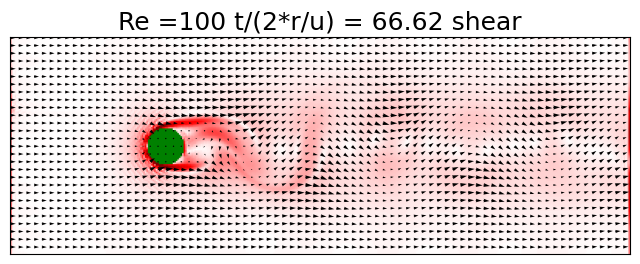

runtime =  14.41  minutes


In [9]:
#####
maxIter=40000#20000
print('run for time steps',maxIter)
# every sub
subIter=int(1.0/uBCLB) #int(maxIter/25)

# time run
tstart = time.time()


print('generating obstacles')
obstacle,binary=obstacle_def(r)

##
# set LHS BC
y=np.linspace(0,ny,ny)
sym_break_perturb=1.0e-1
ux_x0BC=uBCLB*(1.0+sym_break_perturb*np.exp(-(y-ny/3)**2))
print('perturbing left hand BC to break symmetry')


# initial velocities, 0 along y, mostly uBCLB along x
u=np.zeros((2,nx,ny))
u[0,:,:]=uBCLB
# lhs (ie inlet) set
u[0,0,:]=ux_x0BC
# initial conditions are equilibrium for rho = 1 and vel
rho_initial=1.0
feq = equilibrium(rho_initial,u)
# copy equilibrium f into initial f
fin = feq.copy()
#
plot_vorticity=True
plot_vorticity=False
if(plot_vorticity): 
    print('shading is vorticity')
else:
    print('shading is shear magnitude')
savedata=True
savedata=False
if(save_data): print('saving flow fields')
prep_animation()
print('starting run')
###### Main time loop ##########################################################
for tstep in range(maxIter):
# Right wall: outflow condition. Set LB f in last two row on RHS to be equal
# i_set_neg_ux are the 3 vectors with negative x components
# in previous step PBCs will have set these values to values from LH, which need to be
# overwritten
    fin[i_set_neg_ux,-1,:] = fin[i_set_neg_ux,-2,:] 
# sum the 9 components of fin on each lattice site to get density rho at each lattice site
    rho = np.sum(fin,axis=0)         
# Calculate velocity.
#    u = np.dot(c.transpose(), fin.transpose((1,0,2)))/rho
# here for using numpy's einsum, convention is: i is over q lattice vectors,
# j=0 (x) and  1 (y) and m and n are over x and y lattice sites, respectively
    u=np.einsum('imn,ij',fin,lattice_vec,optimize=True)/rho
#    print(u.shape)
    '''
    Zou-He BC at left wall
    '''
# Left wall (ie. at x=0): 1st impose velocity
    u[0,0,:] = ux_x0BC
    u[1,0,:] = 0.0
# after streaming etc rho on left wall is wrong as np.roll applied PBCs there so fin
# with is from i_set_pos_ux are wrong as they rolled round from right hand side
# Zou and He (1997) showed that could compute rho starting from eqs for rho and u and
# eliminating f with i in i_set_pos_ux to get equation:
# compute density at left wall, ie for rho[0,:] overwrite values obtained by summing old fin above
    rho[0,:] = 1./(1.-u[0,0,:]) * \
          (np.sum(fin[i_set_0_ux,0,:],axis=0)+2.0*np.sum(fin[i_set_neg_ux,0,:],axis=0))
    '''
    now compute equilibrium fs, for all lattice including lh wal where we know have correct rho
    '''
    feq = equilibrium(rho,u)
# Left wall: Zou/He boundary condition
# Note that we don't know the fin for is with positive u_x for lh wall sites
# Zou-He said to apply bounce back but only to non-equil bit, eg apply
# bounce back to f_6 - feq_6 etc so here
# bounce back means f_6 - feq_6 = f_3 - feq_3, f_7 - feq_7 = f_4 - feq_4, f_8 - feq_8 = f_5 - feq_5
    fin[i_set_pos_ux,0,:] = fin[i_set_neg_ux,0,:] + feq[i_set_pos_ux,0,:] - feq[i_set_neg_ux,0,:]
# NB can also write fin explictly in terms of know fins, rho and u, see 1997 paper of Zou-He
# that is equivalent to just applying boundeback to non-equil parts of the three f_i, i=6,7,8 
# as we do here
# NB2 In original Palabos code last feq in line above is fin, so fin is just set equal to
# feq at given rho and u, i.e., Palabos code does not quite implement Zou-He BC
# but this difference seems to have very little affect, get same results with it as with
# normal Zou-He BC
# Collision step
    fout = fin - omega * (fin - feq)
# BCs at obstacles: flip all vectors for all cells in obstacle
# eg f for [0 -1] becomes f for [0 1]
    for i in range(q): 
        fout[i,obstacle] = fin[noslip[i],obstacle]
# Streaming step with PBCs implemented using numpy's roll command
    for i in range(q):
        fin[i,:,:] = np.roll(np.roll(fout[i,:,:],lattice_vec[i,0],axis=0),lattice_vec[i,1],axis=1)
# write out stuff
    if(tstep > 1 and tstep%subIter == 0):
        animation_plot()
        if(savedata): save_data()
# Prevent duplicate plot rendering when cell finishes
plt.close(fig)
tend = time.time()
print('runtime = ',round((tend-tstart)/60.0,2),' minutes')
